# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_f1_macro, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_f1_macro"] = pd.to_numeric(df["val_f1_macro"], errors="coerce")
# df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 65
Columns: ['commit', 'val_f1_macro', 'epochs', 'status', 'description']


,commit,val_f1_macro,epochs,status,description
0,a6c5fce,0.7367,6,KEEP,"baseline (cls pool, lr=2e-5, bs=16, hidden=256..."
1,3f0d830,1.0000,10,KEEP,"exp1: LR 2e-5 -> 1e-5 (slower convergence, val..."
2,27939e2,0.7516,7,DISCARD,exp2: drop hidden layer (-> bare linear head);...
3,9733d55,0.7367,7,DISCARD,"exp3: WD 0.01 -> 0; val collapsed, weight_deca..."
4,29f7299,0.8465,10,DISCARD,exp4: pool cls -> mean; val 0.8465 (test 0.884...
5,b471599,0.7367,10,DISCARD,exp5: label_smoothing 0 -> 0.1; val 0.7367 (te...
6,9b8005a,0.7981,9,DISCARD,exp6: dropout 0.1 -> 0.2; val 0.7981 (test 0.8...
7,40014be,0.7814,8,DISCARD,exp7: freeze 2 lower encoder layers; val 0.781...
8,d047ab9,0.8530,6,DISCARD,exp8: BS 16 -> 8; val 0.8530 (best epoch=3)
9,3f96c8d,0.1628,3,CRASH,exp9: BS 16 -> 32; NaN losses on MPS (numerica...


In [ ]:
# дропаем непоказательный эксперимент
df = df.drop(index=[1])

In [3]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    45
CRASH      11
KEEP        8

Keep rate: 8/53 = 15.1%


In [4]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    f1 = row["val_f1_macro"]
    desc = row["description"]
    print(f"  #{i:3d}  f1={f1:.6f}  epochs={row['epochs']}  {desc}")

KEPT experiments (8 total):

  #  0  f1=0.736700  epochs=6  baseline (cls pool, lr=2e-5, bs=16, hidden=256, class_weights, onecycle warmup=0.1)
  # 27  f1=0.871200  epochs=10  exp27: HF_HUB_OFFLINE=1 infra fix (same hyperparams as exp1); val 0.8712 confirms exp1's 1.0 was val=29 lottery. New baseline for further experiments.
  # 34  f1=0.901300  epochs=10  exp34: torch.manual_seed(1); val 0.9013 — improvement over 0.8712 baseline! reproducible.
  # 37  f1=0.909500  epochs=9  exp37: seed=1 + LR 1e-5 -> 1.5e-5; val 0.9095 — improvement! best epoch 6
  # 40  f1=0.909500  epochs=9  exp40: freeze embeddings; val 0.9095 == baseline but -23M trainable params (simplification win, test 0.8766)
  # 53  f1=0.940200  epochs=10  exp53: seed 1 -> 11; val 0.9402 — big jump! best epoch 8, test 0.8183
  # 59  f1=0.958000  epochs=10  exp59: seed 11 -> 42; val 0.9580 — NEW PEAK! best epoch 7, test 0.8448
  # 60  f1=0.972100  epochs=10  exp60: seed=42 + LR 1.5e-5 -> 1.7e-5; val 0.9721 — climbing! best epo

## Val F1-macro Over Time

Track how the best (kept) val_f1_macro evolves as experiments progress. The running maximum shows the "frontier" -- the best result achieved so far.

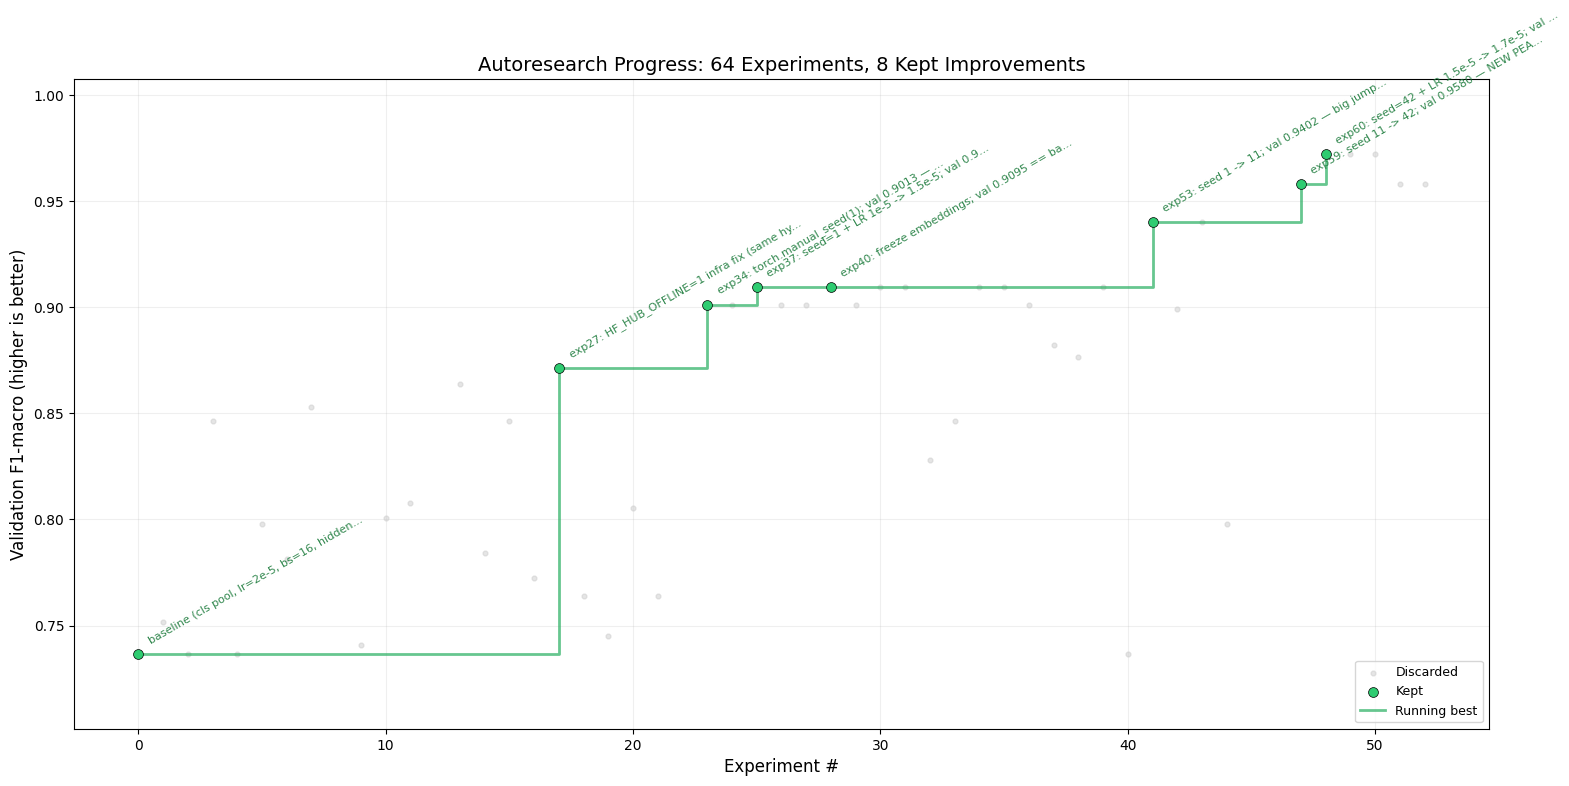

Saved to progress.png


In [5]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_f1 = valid.loc[0, "val_f1_macro"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["val_f1_macro"] >= baseline_f1 - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_f1_macro"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_f1_macro"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_f1 = valid.loc[kept_mask, "val_f1_macro"]
running_max = kept_f1.cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, f1 in zip(kept_idx, kept_f1):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, f1),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation F1-macro (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
best_f1 = kept_f1.max()
margin = (best_f1 - baseline_f1) * 0.15
ax.set_ylim(baseline_f1 - margin, best_f1 + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [6]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_f1 = df.iloc[0]["val_f1_macro"]
best_f1 = kept["val_f1_macro"].max()
best_row = kept.loc[kept["val_f1_macro"].idxmax()]

print(f"Baseline val_f1_macro: {baseline_f1:.6f}")
print(f"Best val_f1_macro:     {best_f1:.6f}")
print(f"Total improvement: {best_f1 - baseline_f1:+.6f} ({(best_f1 - baseline_f1) / baseline_f1 * 100:+.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: f1={row['val_f1_macro']:.6f}  {desc}")

Baseline val_f1_macro: 0.736700
Best val_f1_macro:     0.972100
Total improvement: +0.235400 (+31.95%)
Best experiment:   exp60: seed=42 + LR 1.5e-5 -> 1.7e-5; val 0.9721 — climbing! best epoch 8, test 0.8662

Cumulative effort per improvement:
  Experiment #  0: f1=0.736700  baseline (cls pool, lr=2e-5, bs=16, hidden=256, class_weights, onecycle warmup=0.1)
  Experiment # 27: f1=0.871200  exp27: HF_HUB_OFFLINE=1 infra fix (same hyperparams as exp1); val 0.8712 confirms exp1's 1.0 was val=29 lottery. New baseline for further experiments.
  Experiment # 34: f1=0.901300  exp34: torch.manual_seed(1); val 0.9013 — improvement over 0.8712 baseline! reproducible.
  Experiment # 37: f1=0.909500  exp37: seed=1 + LR 1e-5 -> 1.5e-5; val 0.9095 — improvement! best epoch 6
  Experiment # 40: f1=0.909500  exp40: freeze embeddings; val 0.9095 == baseline but -23M trainable params (simplification win, test 0.8766)
  Experiment # 53: f1=0.940200  exp53: seed 1 -> 11; val 0.9402 — big jump! best epoch 

## Top Hits (Kept Experiments by Improvement)

In [7]:
# Each kept experiment's delta is measured vs the previous kept experiment's f1
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_f1"] = kept["val_f1_macro"].shift(1)
kept["delta"] = kept["val_f1_macro"] - kept["prev_f1"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'F1':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_f1_macro']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta          F1  Description
--------------------------------------------------------------------------------
   1  +0.134500  0.871200  exp27: HF_HUB_OFFLINE=1 infra fix (same hyperparams as exp1); val 0.8712 confirms exp1's 1.0 was val=29 lottery. New baseline for further experiments.
   2  +0.030700  0.940200  exp53: seed 1 -> 11; val 0.9402 — big jump! best epoch 8, test 0.8183
   3  +0.030100  0.901300  exp34: torch.manual_seed(1); val 0.9013 — improvement over 0.8712 baseline! reproducible.
   4  +0.017800  0.958000  exp59: seed 11 -> 42; val 0.9580 — NEW PEAK! best epoch 7, test 0.8448
   5  +0.014100  0.972100  exp60: seed=42 + LR 1.5e-5 -> 1.7e-5; val 0.9721 — climbing! best epoch 8, test 0.8662
   6  +0.008200  0.909500  exp37: seed=1 + LR 1e-5 -> 1.5e-5; val 0.9095 — improvement! best epoch 6
   7  +0.000000  0.909500  exp40: freeze embeddings; val 0.9095 == baseline but -23M trainable params (simplification win, test 0.8766)

      +0.235400              TOTAL im